In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff
import numpy as np
# Read V DEM data
dem_dataV = tiff.imread('Vx.tif')
# Check data shape and range
print("V data shape:", dem_dataV.shape)
print("Maximum value:", np.nanmax(dem_dataV))
# Handle invalid values (if any)
dem_dataV = np.nan_to_num(dem_dataV, nan=0)
dem_dataV = np.where(dem_dataV < 0, 0, dem_dataV)
# If multi-band data, extract the first band
if dem_dataV.ndim == 3:
    dem_dataV = dem_dataV[0]
# Read H DEM data (not used for plotting this time, but keep the reading)
dem_dataH = tiff.imread('Hx.tif')
print("H data shape:", dem_dataH.shape)
print("Maximum value:", np.nanmax(dem_dataH))
dem_dataH = np.nan_to_num(dem_dataH, nan=0)
dem_dataH = np.where(dem_dataH < 0, 0, dem_dataH)
if dem_dataH.ndim == 3:
    dem_dataH = dem_dataH[0]

V data shape: (5196, 6113)
Maximum value: 1.1062523
H data shape: (5196, 6113)
Maximum value: 3.2947693


Loaded 35 cross-sections.


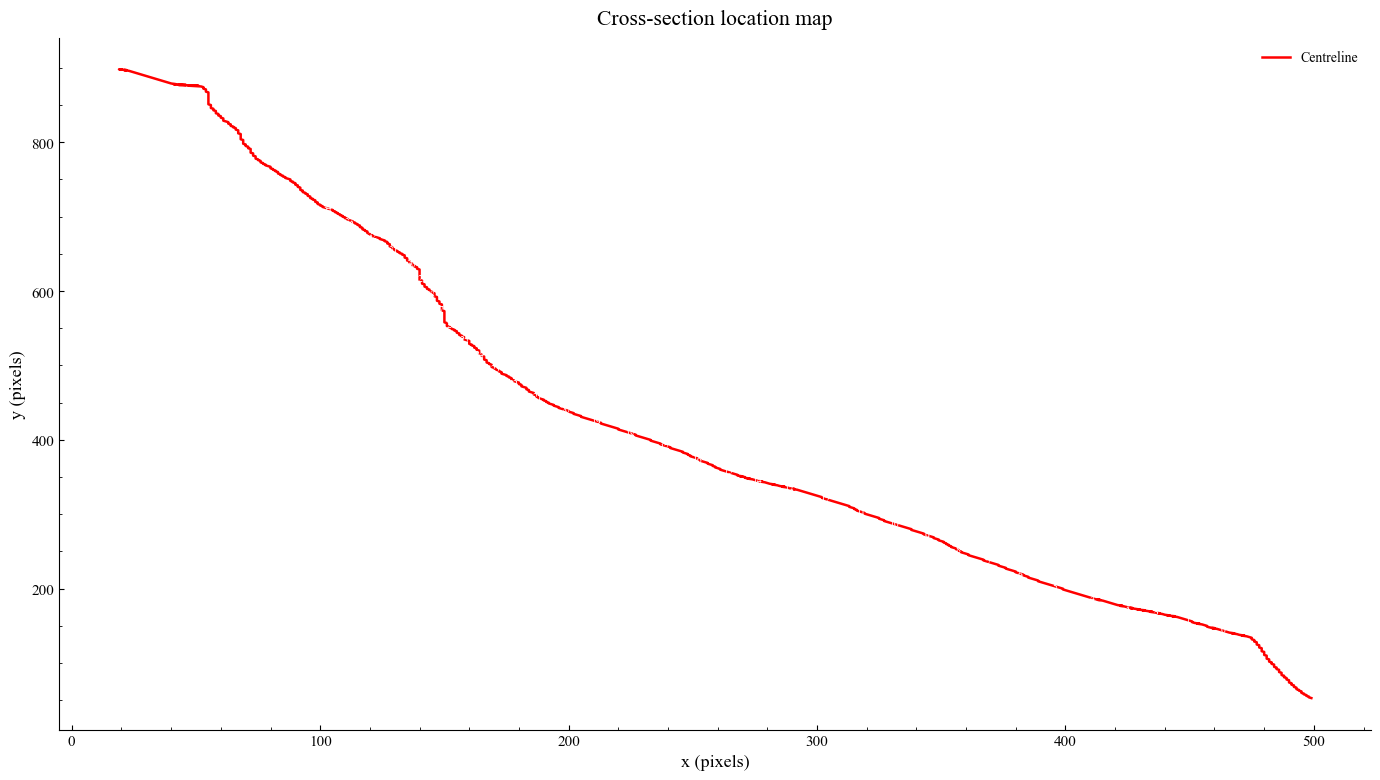

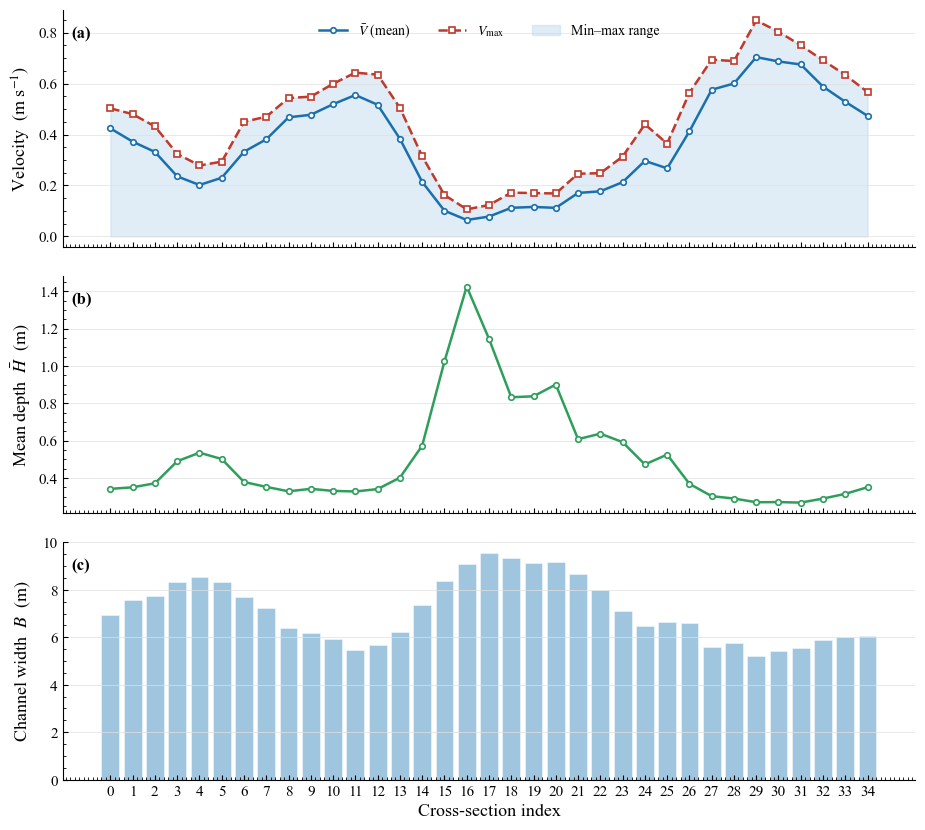

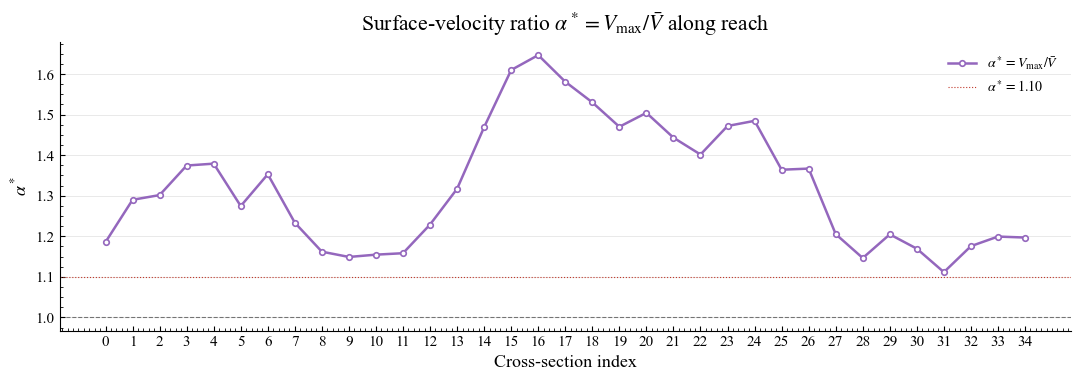

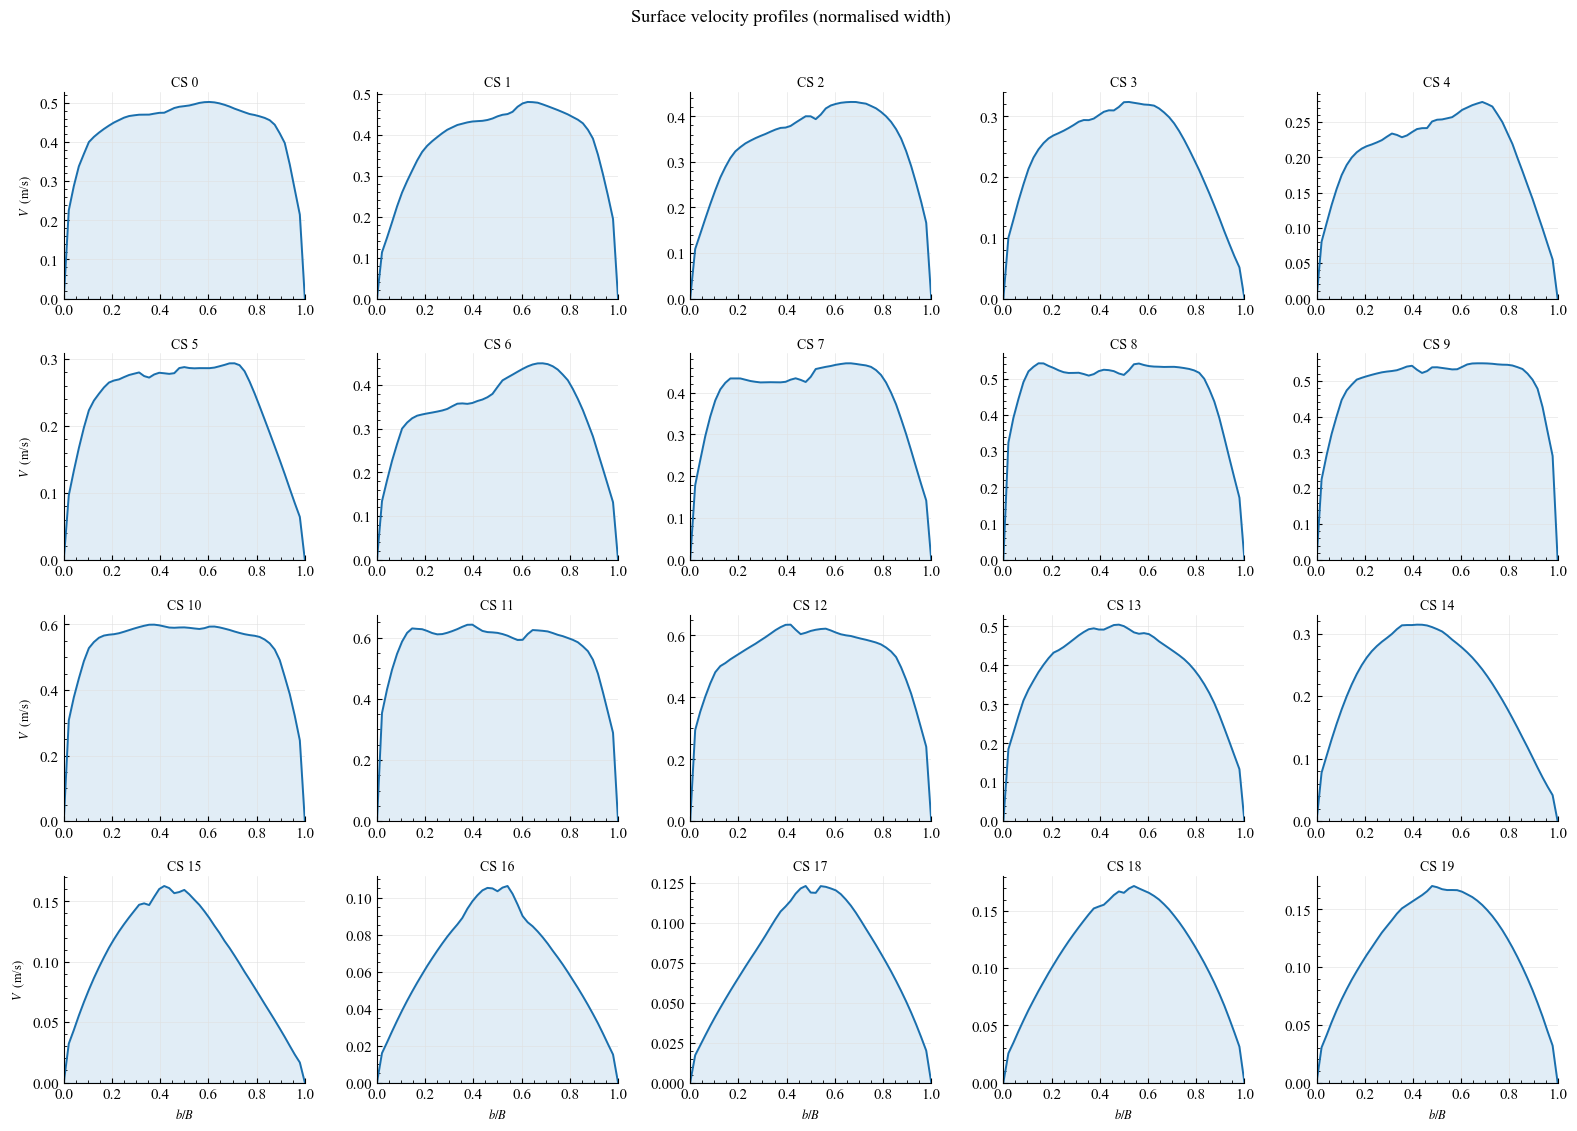


  CS    V_mean     V_max    H_mean         B    alpha
----------------------------------------------------
   0     0.424     0.503     0.341     6.930    1.186
   1     0.372     0.480     0.350     7.580    1.290
   2     0.332     0.432     0.371     7.742    1.302
   3     0.236     0.324     0.489     8.310    1.374
   4     0.202     0.278     0.535     8.559    1.379
   5     0.230     0.294     0.501     8.349    1.275
   6     0.332     0.450     0.378     7.684    1.353
   7     0.381     0.470     0.352     7.220    1.233
   8     0.467     0.543     0.328     6.382    1.162
   9     0.477     0.549     0.341     6.161    1.149
  10     0.519     0.599     0.330     5.920    1.155
  11     0.555     0.643     0.327     5.456    1.158
  12     0.517     0.635     0.340     5.659    1.229
  13     0.383     0.505     0.401     6.224    1.317
  14     0.214     0.314     0.573     7.355    1.469
  15     0.101     0.163     1.024     8.363    1.610
  16     0.065     0.106    

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'stix',
    'font.size':           13,
    'axes.linewidth':      0.8,
    'axes.labelsize':      13,
    'xtick.labelsize':     11,
    'ytick.labelsize':     11,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'axes.unicode_minus':  False,
    'legend.frameon':      False,
})
C_GRID = '#E0E0E0'

# ── Load data ─────────────────────────────────────────────────────────────────
data_path = 'river1.npy'   # ← change path if needed
results = np.load(data_path, allow_pickle=True).item()

centerline_points   = results['centerline']           # (N, 2)
smooth_cross_sections = results['cross_sections']     # list of cross-section coords
cross_section_data  = results['velocity_distributions']  # list of dicts

n_sections = len(cross_section_data)
print(f"Loaded {n_sections} cross-sections.")

# ── Extract per-section statistics ───────────────────────────────────────────
idx          = np.arange(n_sections)
v_mean       = np.array([np.mean(d['velocities']) for d in cross_section_data])
v_max        = np.array([np.max(d['velocities'])  for d in cross_section_data])
v_min        = np.array([np.min(d['velocities'])  for d in cross_section_data])
H_mean       = np.array([d['H']                   for d in cross_section_data])
B_width      = np.array([d['Bottom width']         for d in cross_section_data])
alpha        = v_max / np.where(v_mean > 0, v_mean, np.nan)   # α = Vmax / Vmean

# ── Figure 1: Plan view ───────────────────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(14, 8))
ax.plot(centerline_points[:, 0], centerline_points[:, 1],
        'r-', lw=1.8, label='Centreline', zorder=3)

for i, cs in enumerate(smooth_cross_sections):
    cs = np.array(cs)
    ax.plot(cs[:, 0], cs[:, 1], 'w-', lw=0.8, alpha=0.5, zorder=2)
    mid = cs.mean(axis=0)
    ax.text(mid[0], mid[1], str(i), color='white',
            fontsize=7, ha='center', va='center', zorder=4)

ax.set_title('Cross-section location map', pad=10)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('y (pixels)')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('plan_view.png', dpi=200, bbox_inches='tight')

# ── Figure 2: Velocity statistics along reach ─────────────────────────────────
fig2, axes = plt.subplots(3, 1, figsize=(11, 10),
                           sharex=True,
                           gridspec_kw={'hspace': 0.12})

def fmt_ax(ax, ylabel, panel_label):
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', color=C_GRID, lw=0.5)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.01, 0.93, panel_label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top')

# (a) mean / max velocity
axes[0].plot(idx, v_mean, 'o-', color='#1A6FAD', lw=1.8, ms=4,
             markerfacecolor='white', markeredgewidth=1.2,
             label=r'$\bar{V}$ (mean)')
axes[0].plot(idx, v_max,  's--', color='#C0392B', lw=1.8, ms=4,
             markerfacecolor='white', markeredgewidth=1.2,
             label=r'$V_{\max}$')
axes[0].fill_between(idx, v_min, v_max,
                     color='#AACDE8', alpha=0.35, label='Min–max range')
axes[0].legend(fontsize=10, ncol=3)
fmt_ax(axes[0], r'Velocity  (m s$^{-1}$)', '(a)')

# (b) mean water depth
axes[1].plot(idx, H_mean, 'o-', color='#2E9E5B', lw=1.8, ms=4,
             markerfacecolor='white', markeredgewidth=1.2)
fmt_ax(axes[1], r'Mean depth  $\bar{H}$  (m)', '(b)')

# (c) channel width
axes[2].bar(idx, B_width, color='#7FB3D3', alpha=0.75, edgecolor='white', lw=0.4)
fmt_ax(axes[2], r'Channel width  $B$  (m)', '(c)')
axes[2].set_xlabel('Cross-section index')
axes[2].set_xticks(idx)

fig2.align_ylabels(axes)
# plt.savefig('reach_statistics.png', dpi=200, bbox_inches='tight')

# ── Figure 3: α = Vmax / Vmean along reach ───────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(11, 4))
ax3.plot(idx, alpha, 'o-', color='#9467BD', lw=1.8, ms=4,
         markerfacecolor='white', markeredgewidth=1.2, label=r'$\alpha^* = V_{\max}/\bar{V}$')
ax3.axhline(1.0,  color='k',       lw=0.8, ls='--', alpha=0.5)
ax3.axhline(1.10, color='#C0392B', lw=0.8, ls=':',  label=r'$\alpha^* = 1.10$')
ax3.set_xlabel('Cross-section index')
ax3.set_ylabel(r'$\alpha^*$')
ax3.set_title(r'Surface-velocity ratio $\alpha^* = V_{\max}/\bar{V}$ along reach', pad=8)
ax3.set_xticks(idx)
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax3.grid(axis='y', color=C_GRID, lw=0.5)
ax3.spines[['top', 'right']].set_visible(False)
ax3.legend(fontsize=10)
plt.tight_layout()
# plt.savefig('alpha_distribution.png', dpi=200, bbox_inches='tight')

# ── Figure 4: Individual cross-section velocity profiles ─────────────────────
# Plot every cross-section on a grid (max 20 shown for readability)
n_show = min(n_sections, 20)
ncols  = 5
nrows  = int(np.ceil(n_show / ncols))

fig4, axes4 = plt.subplots(nrows, ncols,
                            figsize=(ncols * 3.2, nrows * 2.8),
                            sharey=False)
axes4 = axes4.flatten()

for i in range(n_show):
    d   = cross_section_data[i]
    dist = np.array(d['distances'])
    vel  = np.array(d['velocities'])
    # normalise distance to [0, 1]
    dist_norm = (dist - dist.min()) / (dist.max() - dist.min() + 1e-12)
    axes4[i].plot(dist_norm, vel, '-', color='#1A6FAD', lw=1.4)
    axes4[i].fill_between(dist_norm, 0, vel,
                           color='#AACDE8', alpha=0.35)
    axes4[i].set_title(f'CS {i}', fontsize=10, pad=4)
    axes4[i].set_xlim(0, 1)
    axes4[i].set_ylim(bottom=0)
    axes4[i].grid(color=C_GRID, lw=0.4)
    axes4[i].spines[['top', 'right']].set_visible(False)
    if i % ncols == 0:
        axes4[i].set_ylabel(r'$V$  (m/s)', fontsize=9)
    if i >= (nrows - 1) * ncols:
        axes4[i].set_xlabel(r'$b/B$', fontsize=9)

# hide unused subplots
for j in range(n_show, len(axes4)):
    axes4[j].set_visible(False)

fig4.suptitle('Surface velocity profiles (normalised width)', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('velocity_profiles_grid.png', dpi=200, bbox_inches='tight')

plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print(f"\n{'CS':>4} {'V_mean':>9} {'V_max':>9} {'H_mean':>9} {'B':>9} {'alpha':>8}")
print("-" * 52)
for i in range(n_sections):
    print(f"{i:>4} {v_mean[i]:>9.3f} {v_max[i]:>9.3f} "
          f"{H_mean[i]:>9.3f} {B_width[i]:>9.3f} {alpha[i]:>8.3f}")